In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gitikadhingra","key":"KGAT_1a570eea450f60c2c8e3c1b63575a918"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:02<00:00, 290MB/s]



In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *

In [ ]:
DATASET_PATH = "PlantVillage"

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    for img in os.listdir(os.path.join(DATASET_PATH, class_name)):
        image_paths.append(os.path.join(DATASET_PATH, class_name, img))
        labels.append(class_name)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

train_df = pd.DataFrame({"filename": train_paths, "class": train_labels})
val_df   = pd.DataFrame({"filename": val_paths, "class": val_labels})

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_base = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    train_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_base = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    val_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

steps_base = train_base.samples // BATCH_SIZE
val_steps  = val_base.samples // BATCH_SIZE

NUM_CLASSES = len(train_df['class'].unique())

Found 16510 validated image filenames belonging to 15 classes.
Found 4128 validated image filenames belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
model_cnn = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    train_base,
    validation_data=val_base,
    epochs=10,
    steps_per_epoch=steps_base,
    validation_steps=val_steps
)

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.5850 - loss: 1.3034 - val_accuracy: 0.7754 - val_loss: 0.6424
Epoch 2/10
  1/515 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.5312 - loss: 1.3809

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5312 - loss: 1.3809 - val_accuracy: 0.7992 - val_loss: 0.5942
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 68s 74ms/step - accuracy: 0.7802 - loss: 0.6596 - val_accuracy: 0.8406 - val_loss: 0.4629
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8750 - loss: 0.4454 - val_accuracy: 0.8547 - val_loss: 0.4426
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.8444 - loss: 0.4579 - val_accuracy: 0.8651 - val_loss: 0.3933
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9375 - loss: 0.3285 - val_accuracy: 0.8665 - val_loss: 0.3985
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8841 - loss: 0.3433 - val_accuracy: 0.8939 - val_loss: 0.3053
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8750 - loss: 0.2699 - val_accuracy: 0.9007 - val_loss: 0.2932
Epoch 9/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.9079 - loss: 0.2667 - val_accuracy: 0

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_mob = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_dataframe(
    train_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_mob = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    val_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 16510 validated image filenames belonging to 15 classes.
Found 4128 validated image filenames belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_mob = MobileNetV2(input_shape=(224,224,3),
                       include_top=False,
                       weights='imagenet')

base_mob.trainable = False

x = base_mob.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

model_mob = Model(inputs=base_mob.input, outputs=output)

model_mob.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mob = model_mob.fit(
    train_mob,
    validation_data=val_mob,
    epochs=10,
    steps_per_epoch=steps_base,
    validation_steps=val_steps
)

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 224s 416ms/step - accuracy: 0.6847 - loss: 0.9840 - val_accuracy: 0.8525 - val_loss: 0.4558
Epoch 2/10
  1/515 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7812 - loss: 0.8464

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7812 - loss: 0.8464 - val_accuracy: 0.8517 - val_loss: 0.4563
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 241s 397ms/step - accuracy: 0.8025 - loss: 0.5871 - val_accuracy: 0.8798 - val_loss: 0.3770
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7812 - loss: 0.5219 - val_accuracy: 0.8769 - val_loss: 0.3793
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 205s 397ms/step - accuracy: 0.8271 - loss: 0.5193 - val_accuracy: 0.8844 - val_loss: 0.3548
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7500 - loss: 0.5869 - val_accuracy: 0.8854 - val_loss: 0.3512
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 203s 394ms/step - accuracy: 0.8443 - loss: 0.4657 - val_accuracy: 0.8944 - val_loss: 0.3287
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9062 - loss: 0.3901 - val_accuracy: 0.8922 - val_loss: 0.3325
Epoch 9/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 202s 392ms/step - accuracy: 0.8526 - loss: 0.4432 - val_acc

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_dataframe(
    train_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    val_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 16510 validated image filenames belonging to 15 classes.
Found 4128 validated image filenames belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_dataframe(
    train_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    val_df, x_col="filename", y_col="class",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 16510 validated image filenames belonging to 15 classes.
Found 4128 validated image filenames belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_eff = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_eff.trainable = False

x = base_eff.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

model_eff = Model(inputs=base_eff.input, outputs=output)

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff = model_eff.fit(
    train_eff,
    validation_data=val_eff,
    epochs=10,
    steps_per_epoch=steps_base,
    validation_steps=val_steps
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 250s 434ms/step - accuracy: 0.7801 - loss: 0.7209 - val_accuracy: 0.9058 - val_loss: 0.2857
Epoch 2/10
  1/515 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.8125 - loss: 0.5512

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8125 - loss: 0.5512 - val_accuracy: 0.9050 - val_loss: 0.2881
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 206s 400ms/step - accuracy: 0.8755 - loss: 0.3762 - val_accuracy: 0.9043 - val_loss: 0.2916
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8750 - loss: 0.3240 - val_accuracy: 0.9026 - val_loss: 0.2921
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 205s 398ms/step - accuracy: 0.8911 - loss: 0.3296 - val_accuracy: 0.9317 - val_loss: 0.2114
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8125 - loss: 0.6911 - val_accuracy: 0.9314 - val_loss: 0.2133
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 206s 401ms/step - accuracy: 0.9078 - loss: 0.2791 - val_accuracy: 0.9416 - val_loss: 0.1772
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8438 - loss: 0.6395 - val_accuracy: 0.9409 - val_loss: 0.1770
Epoch 9/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 205s 399ms/step - accuracy: 0.9096 - loss: 0.2729 - val_a

129/129 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step

Baseline
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       199
           1       0.89      0.99      0.93       296
           2       0.95      0.94      0.95       200
           3       0.82      0.86      0.84       200
           4       0.88      0.50      0.64        30
           5       0.94      0.96      0.95       426
           6       0.87      0.67      0.75       200
           7       0.85      0.86      0.86       382
           8       0.88      0.82      0.85       190
           9       0.80      0.94      0.87       354
          10       0.92      0.93      0.92       335
          11       0.94      0.84      0.89       281
          12       0.96      0.99      0.98       642
          13       0.93      0.99      0.95        75
          14       0.99      0.97      0.98       318

    accuracy                           0.91      4128
   macro avg       0.90   

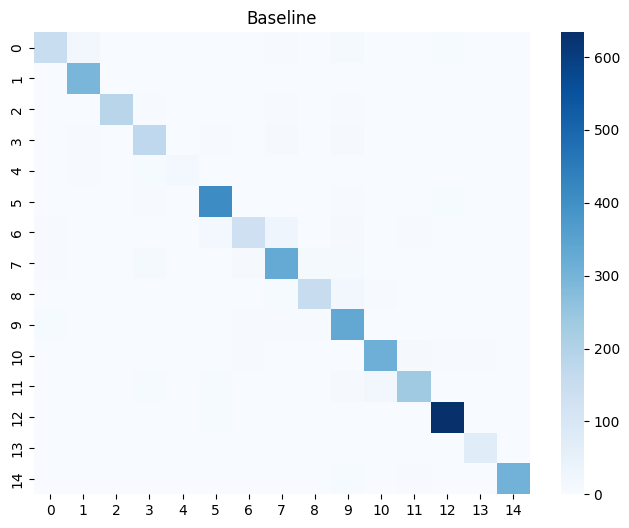

129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step

MobileNet
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       199
           1       0.96      0.99      0.98       296
           2       0.97      0.95      0.96       200
           3       0.93      0.92      0.92       200
           4       0.93      0.83      0.88        30
           5       0.92      0.88      0.90       426
           6       0.82      0.67      0.73       200
           7       0.92      0.87      0.89       382
           8       0.77      0.91      0.83       190
           9       0.81      0.91      0.86       354
          10       0.88      0.86      0.87       335
          11       0.81      0.81      0.81       281
          12       0.99      0.97      0.98       642
          13       0.98      0.63      0.76        75
          14       0.85      0.99      0.91       318

    accuracy                           0.90      4128
   macro avg       0.90   

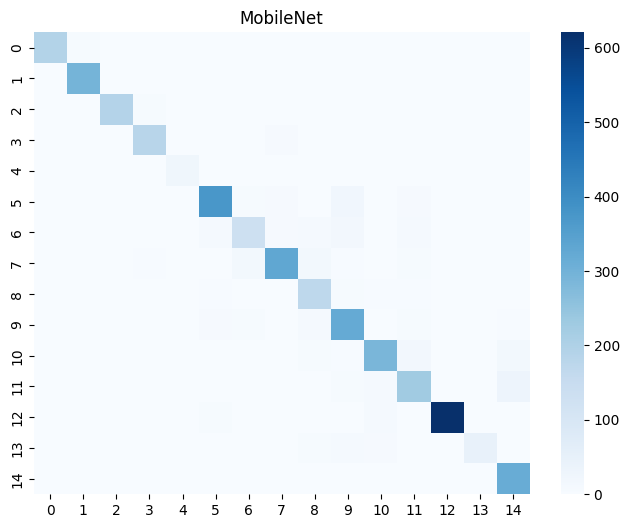

129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step

EfficientNet
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       199
           1       0.98      0.99      0.99       296
           2       0.99      0.92      0.96       200
           3       0.92      0.98      0.95       200
           4       0.96      0.77      0.85        30
           5       0.96      0.96      0.96       426
           6       0.97      0.72      0.83       200
           7       0.94      0.97      0.95       382
           8       0.98      0.89      0.93       190
           9       0.87      0.95      0.91       354
          10       0.90      0.97      0.93       335
          11       0.87      0.91      0.89       281
          12       0.99      0.98      0.98       642
          13       0.97      0.85      0.91        75
          14       0.96      0.97      0.96       318

    accuracy                           0.95      4128
   macro avg       0.95

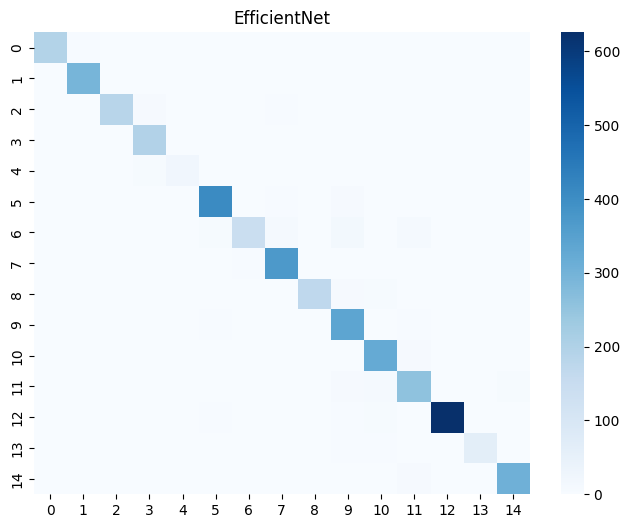

In [ ]:
def evaluate(model, data, name):
    data.reset()
    y_pred = np.argmax(model.predict(data), axis=1)
    y_true = data.classes

    print(f"\n{name}")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap='Blues')
    plt.title(name)
    plt.show()

    return classification_report(y_true, y_pred, output_dict=True)

r1 = evaluate(model_cnn, val_base, "Baseline")
r2 = evaluate(model_mob, val_mob, "MobileNet")
r3 = evaluate(model_eff, val_eff, "EfficientNet")

In [ ]:
def get_metrics(r):
    return r["accuracy"], r["macro avg"]["f1-score"]

a1,f1 = get_metrics(r1)
a2,f2 = get_metrics(r2)
a3,f3 = get_metrics(r3)

print("\nFINAL RESULTS")
print("Model\tAccuracy\tF1")
print(f"CNN\t{a1:.3f}\t{f1:.3f}")
print(f"MobileNet\t{a2:.3f}\t{f2:.3f}")
print(f"EfficientNet\t{a3:.3f}\t{f3:.3f}")


FINAL RESULTS
Model	Accuracy	F1
CNN	0.906	0.878
MobileNet	0.900	0.884
EfficientNet	0.945	0.932


In [ ]:
model_eff.save("final_model.h5")

In [ ]:
def classwise_accuracy(model, data, name):
    data.reset()
    y_pred = np.argmax(model.predict(data), axis=1)
    y_true = data.classes

    cm = confusion_matrix(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)

    classes = list(data.class_indices.keys())

    print(f"\n=== {name} Class-wise Accuracy ===")
    for i, acc in enumerate(class_acc):
        print(f"{classes[i]}: {acc*100:.2f}%")

    return cm, class_acc

In [ ]:
cm_cnn, acc_cnn = classwise_accuracy(model_cnn, val_base, "CNN")
cm_mob, acc_mob = classwise_accuracy(model_mob, val_mob, "MobileNet")
cm_eff, acc_eff = classwise_accuracy(model_eff, val_eff, "EfficientNet")

129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step

=== CNN Class-wise Accuracy ===
Pepper__bell___Bacterial_spot: 75.88%
Pepper__bell___healthy: 98.99%
Potato___Early_blight: 94.00%
Potato___Late_blight: 86.50%
Potato___healthy: 50.00%
Tomato_Bacterial_spot: 95.54%
Tomato_Early_blight: 66.50%
Tomato_Late_blight: 86.13%
Tomato_Leaf_Mold: 82.11%
Tomato_Septoria_leaf_spot: 93.79%
Tomato_Spider_mites_Two_spotted_spider_mite: 93.43%
Tomato__Target_Spot: 83.99%
Tomato__Tomato_YellowLeaf__Curl_Virus: 98.75%
Tomato__Tomato_mosaic_virus: 98.67%
Tomato_healthy: 96.54%
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

=== MobileNet Class-wise Accuracy ===
Pepper__bell___Bacterial_spot: 96.48%
Pepper__bell___healthy: 99.32%
Potato___Early_blight: 95.50%
Potato___Late_blight: 91.50%
Potato___healthy: 83.33%
Tomato_Bacterial_spot: 88.03%
Tomato_Early_blight: 66.50%
Tomato_Late_blight: 86.91%
Tomato_Leaf_Mold: 90.53%
Tomato_Septoria_leaf_spot: 90.68%
Tomato_Spider_mites_Two_spotted_spider_mite: 85.97%
Tomato__Targe

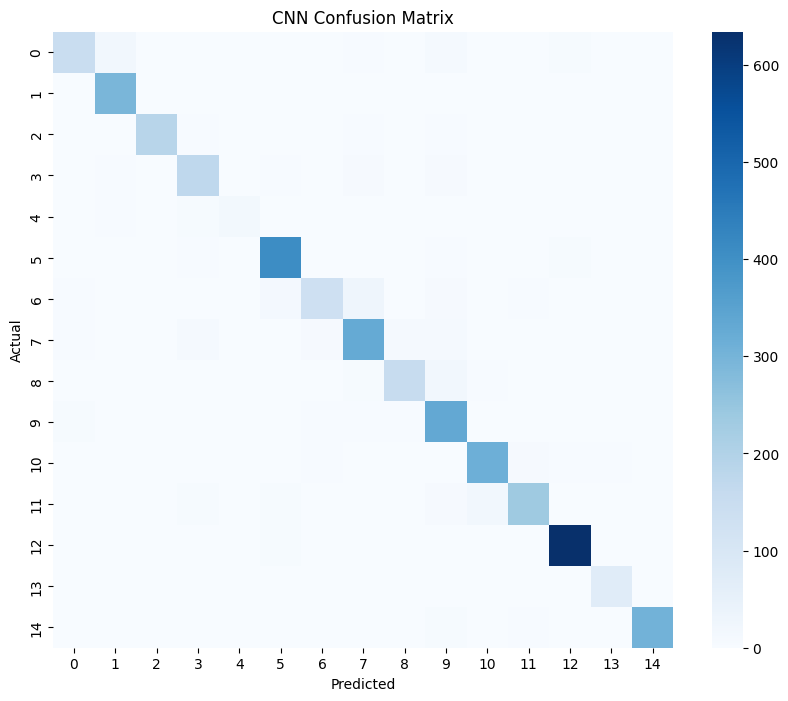

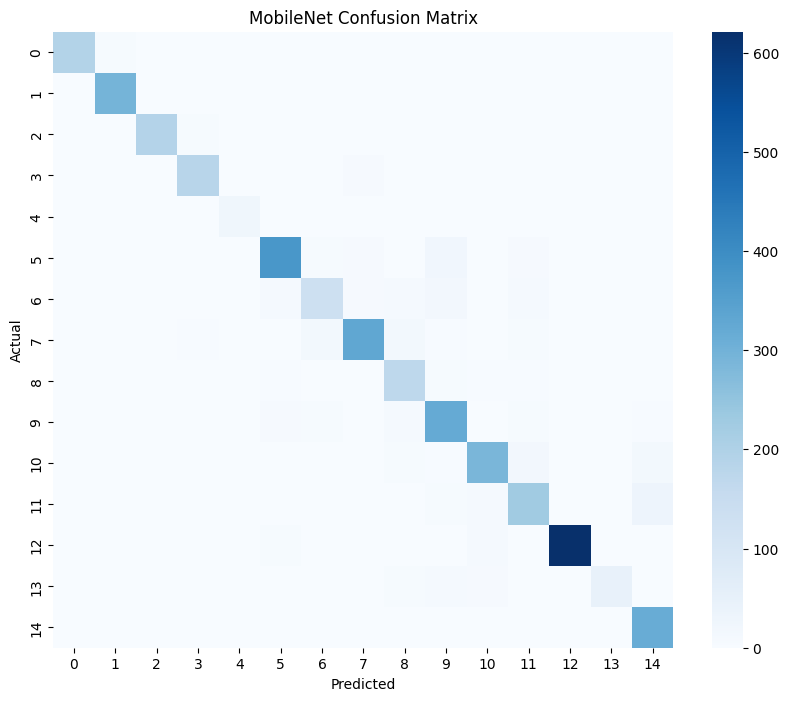

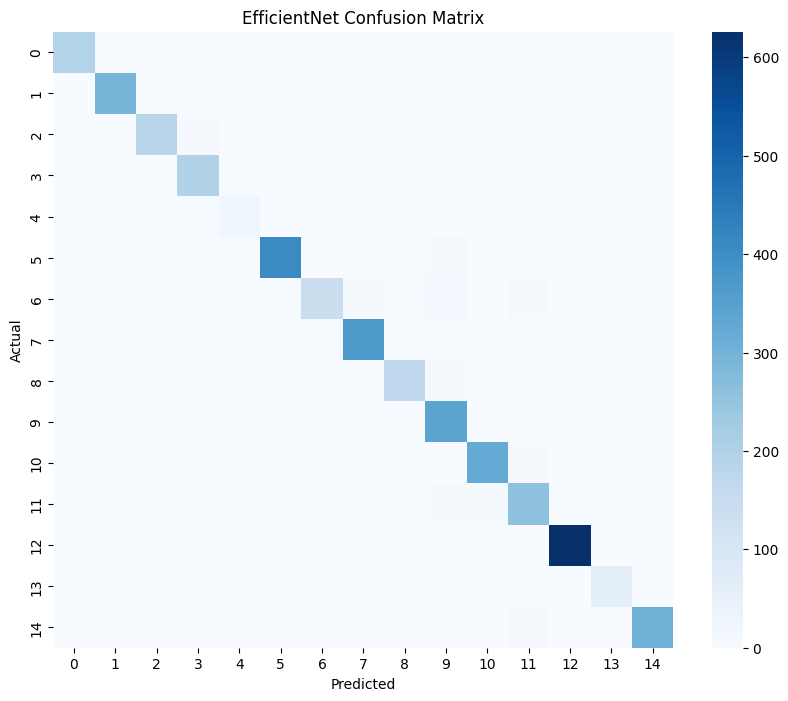

In [ ]:
def save_cm(cm, title, filename):
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

save_cm(cm_cnn, "CNN Confusion Matrix", "cnn_cm.png")
save_cm(cm_mob, "MobileNet Confusion Matrix", "mob_cm.png")
save_cm(cm_eff, "EfficientNet Confusion Matrix", "eff_cm.png")

In [ ]:
import cv2
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap

In [ ]:
last_conv_layer = "top_conv"

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_356']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


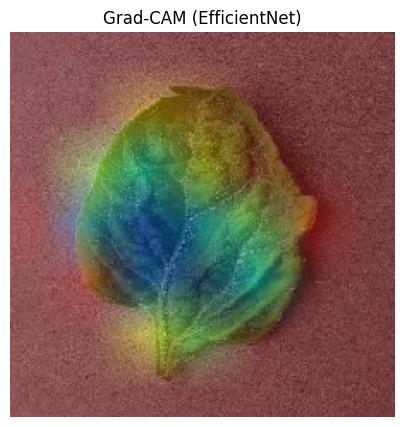

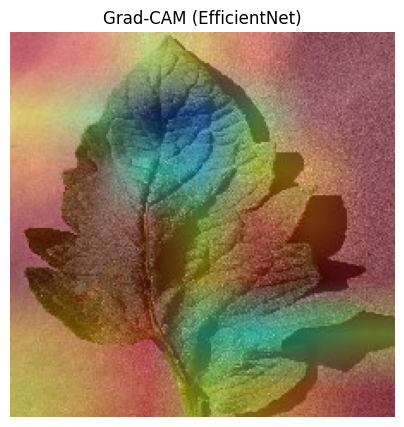

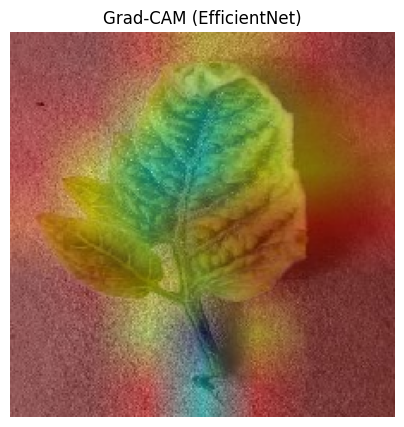

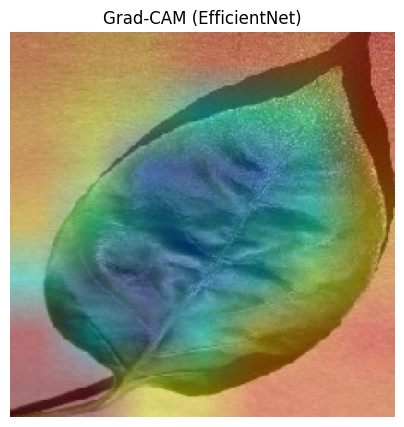

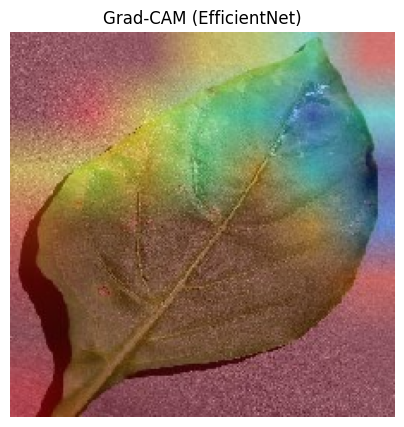

In [ ]:
from tensorflow.keras.preprocessing import image
import random

indices = random.sample(range(len(val_eff.filepaths)), 5)

for i in indices:
    img_path = val_eff.filepaths[i]

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model_eff, last_conv_layer)

    heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)

    img_orig = np.uint8(img_array[0])
    heatmap = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))

    overlay = cv2.addWeighted(img_orig, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.title("Grad-CAM (EfficientNet)")
    plt.axis('off')
    plt.show()

In [ ]:
plt.imsave("gradcam_sample.png", overlay)

In [ ]:
model_eff.save("final_model.h5")

np.save("cnn_classwise.npy", acc_cnn)
np.save("mob_classwise.npy", acc_mob)
np.save("eff_classwise.npy", acc_eff)

In [ ]:
from google.colab import files

files.download("final_model.h5")
files.download("eff_cm.png")
files.download("gradcam_sample.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=856292cbf064c6193493fe47a7ae9b6d85d15e7ed1a9c4e353ed3a04dcaab866
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━

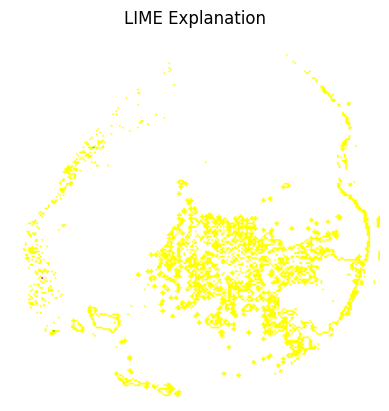

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

# pick 1 image
img_path = val_eff.filepaths[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

def predict_fn(images):
    images = images / 255.0
    return model_eff.predict(images)

explanation = explainer.explain_instance(
    img_array.astype('double'),
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=500   # keep low for speed
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()

In [ ]:
!pip install shap

import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Take small batch from validation generator
val_eff.reset()
X_batch, _ = next(val_eff)

# Background (for SHAP baseline)
background = X_batch[:20]   # small set

# Test images to explain
test_images = X_batch[20:25]  # 5 images only

In [ ]:
explainer = shap.GradientExplainer(model_eff, background)

In [ ]:
shap_values = explainer.shap_values(test_images)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_356
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_356
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


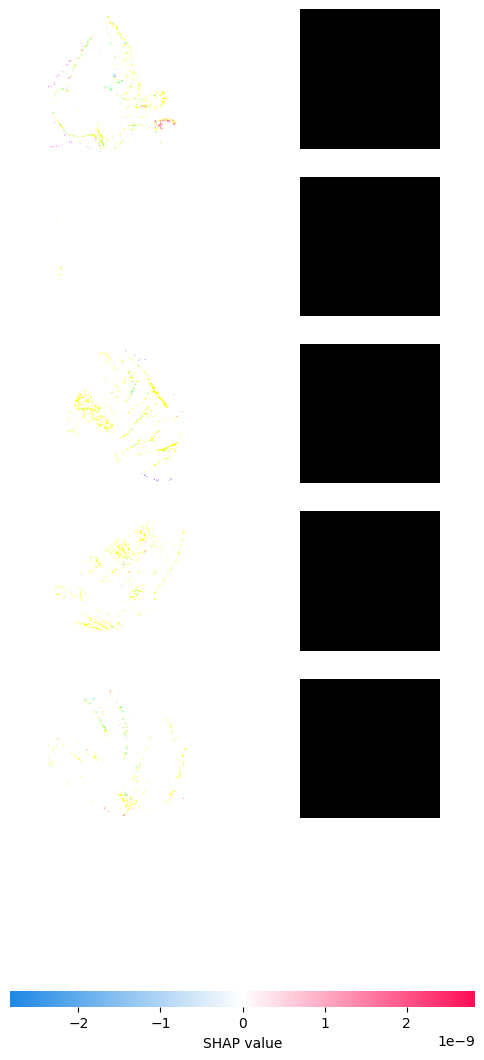

In [ ]:
shap.image_plot(shap_values, test_images)